# Week7 - Tree Assignment

- Load the breast cancer dataset using datasets.load_breast_cancer()
- Use scatter plots to look at the data (use different colors for the classes)
- Use box plots to look at the data
- create a training and test set with random_state = 3
- train a decision tree model on the training set.
- train a logistic regression model on the training set
- train a random forest model on the training set
- Which model performed better?
- Which features were most relevant in each model (a part from random forest)?
- Use grid search to improve performance on the best performed model

In [18]:
# importing all the required libraries 
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

In [19]:
#loading breast cancer data
data = load_breast_cancer()
print(data.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


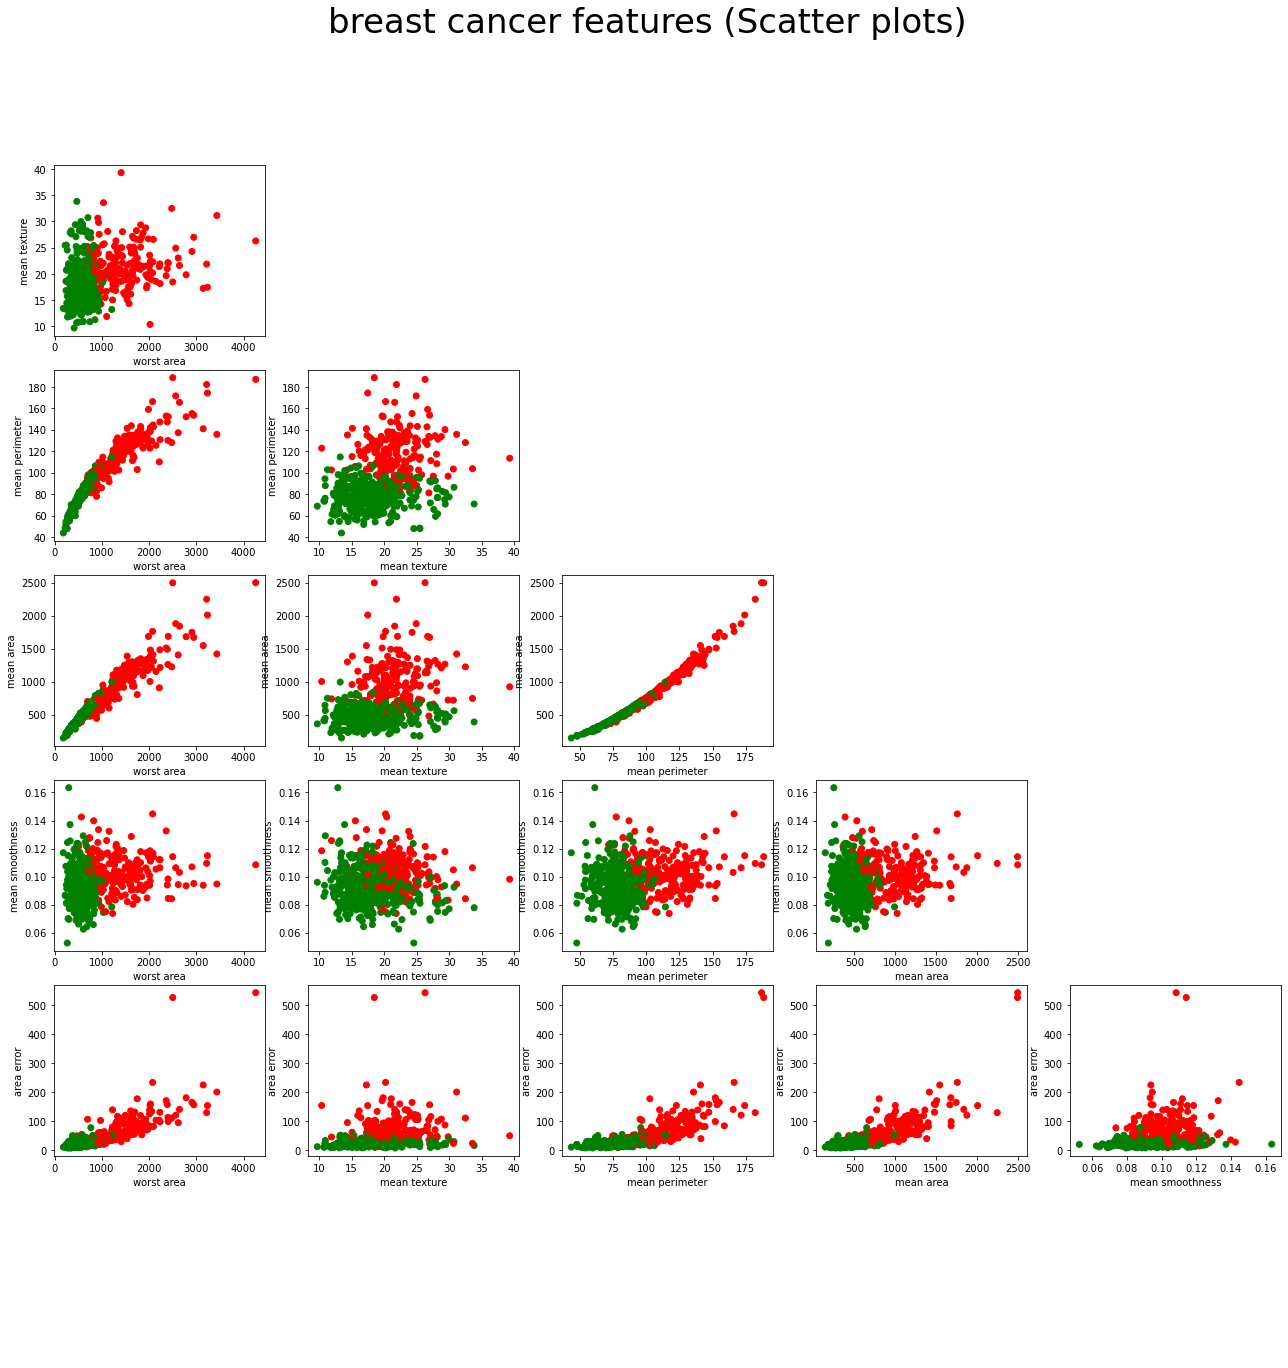

In [20]:
# Select a subset of features for visualization
feature_names = ['worst area', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'area error']
X = data.data[:, [data.feature_names.tolist().index(feature) for feature in feature_names]]
y = data.target

# adding colors to classes, red if label is 0, green if label is 1
colors = ['red' if label == 0 else 'green' for label in y]

# plotting for the above features
fig, axs = plt.subplots(nrows=6, ncols=5, figsize=(22, 22))
for i in range(6):
    for j in range(5):
        if j < i:
            axs[i-1, j].scatter(X[:, j], X[:, i], color=colors)
            axs[i-1, j].set_xlabel(feature_names[j])
            axs[i-1, j].set_ylabel(feature_names[i])
        else:
            axs[i-1, j].axis('off')
    
fig.suptitle('breast cancer features (Scatter plots)', fontsize = 34)

plt.show()

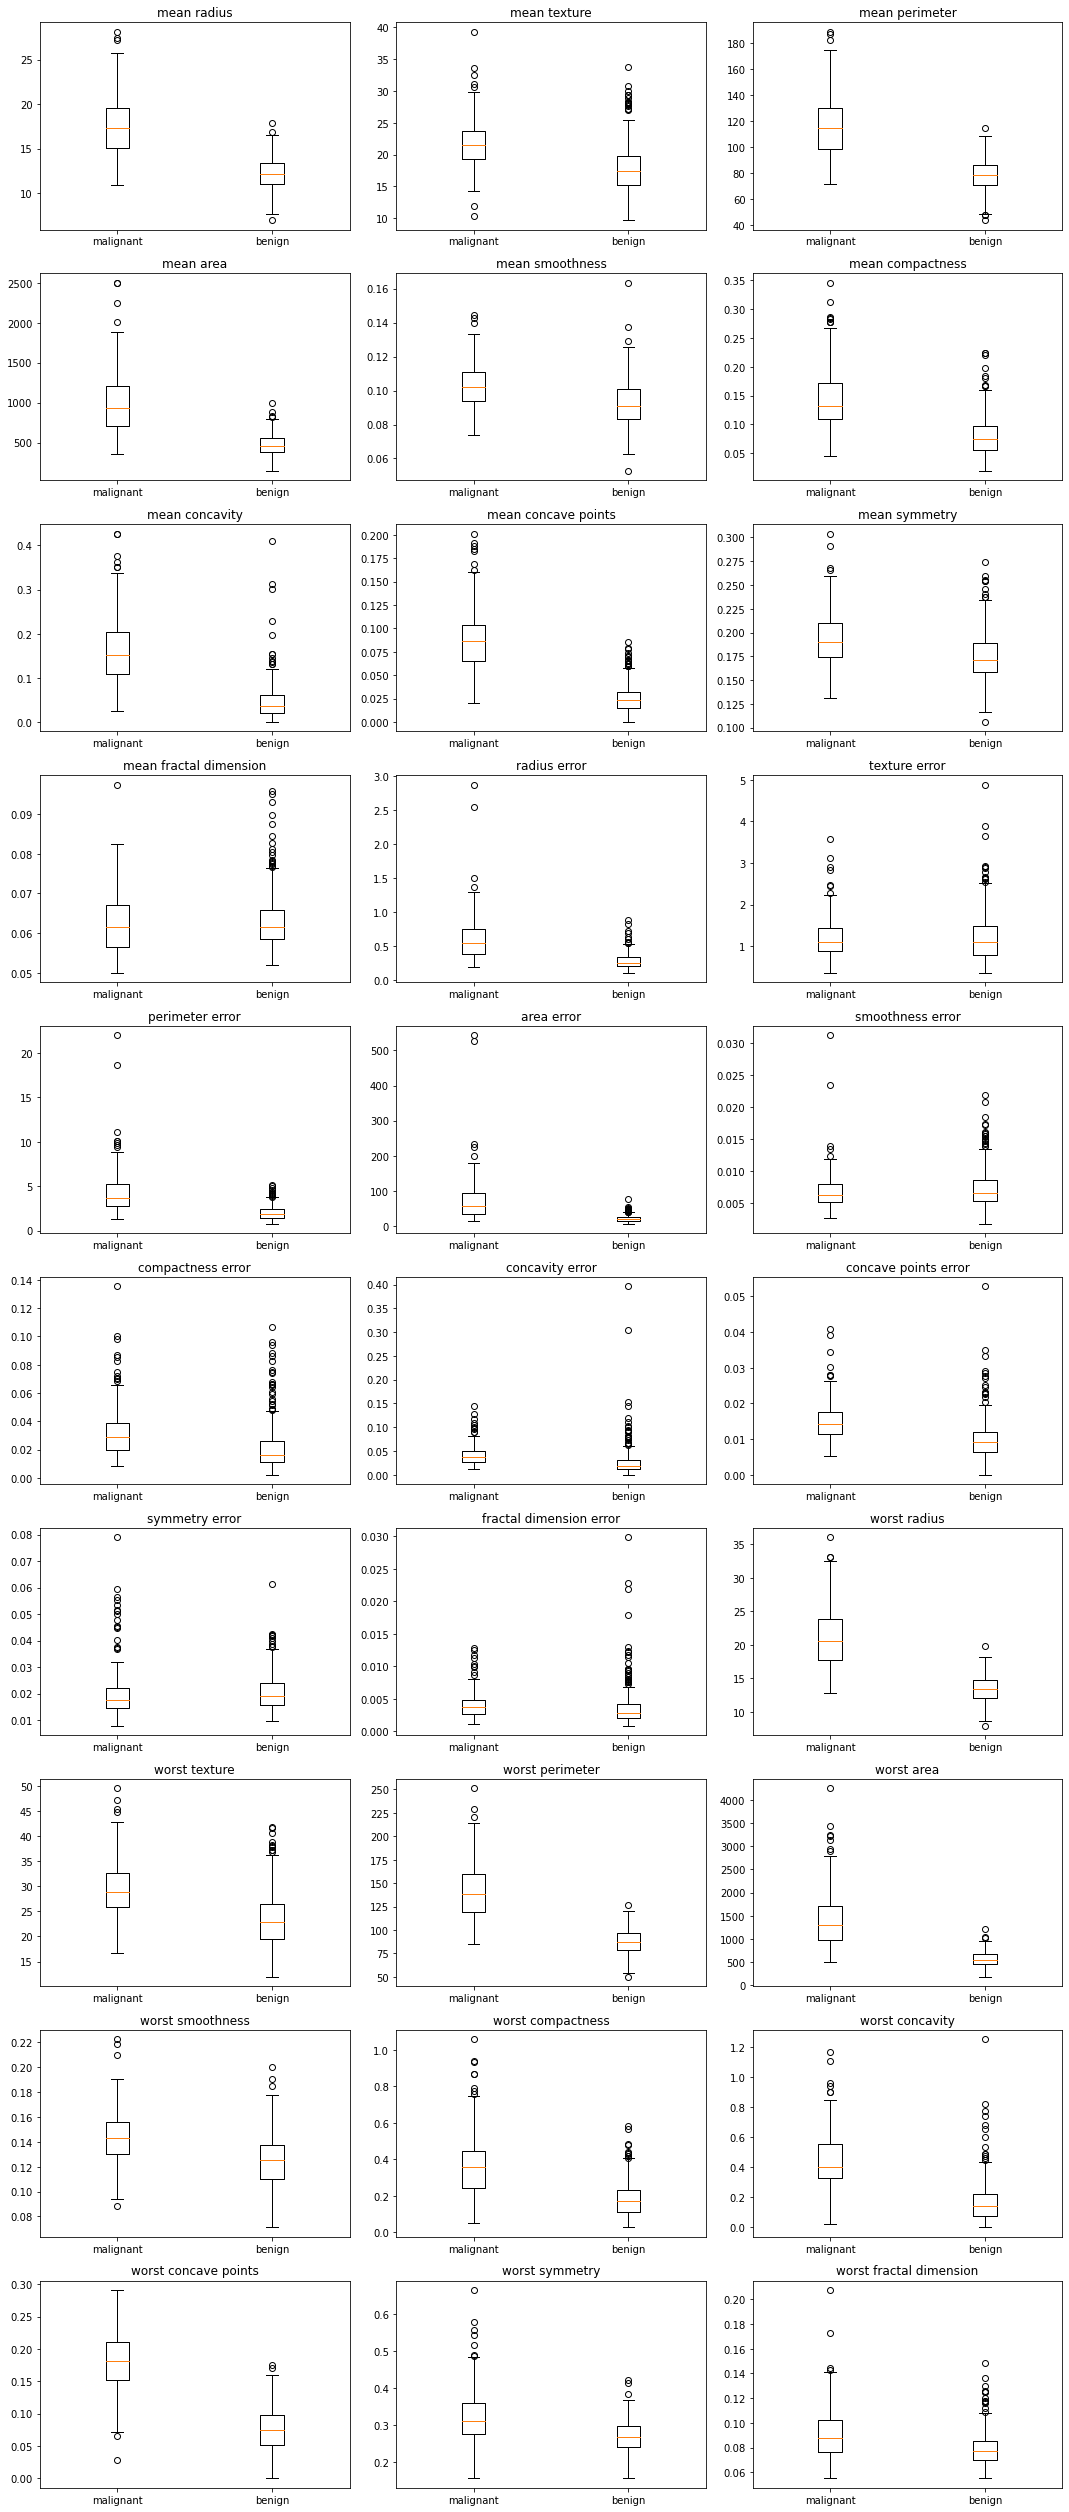

In [21]:
# creating box plots for all features,
fig, axs = plt.subplots(nrows=10, ncols=3, figsize=(15, 35))
for i, ax in enumerate(axs.flatten()):
    ax.boxplot([data.data[data.target==0, i], data.data[data.target==1, i]], labels=['malignant', 'benign'])
    ax.set_title(data.feature_names[i])
plt.tight_layout()
plt.show()

In [22]:
# splitting the data into train and test and use standard scaller on the input data
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, random_state=3)

In [23]:
#scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# train a decision tree model on the training set
dtc_model = DecisionTreeClassifier(random_state=3)
dtc_model.fit(X_train_scaled, y_train)
print('Decision Tree accuracy:', dtc_model.score(X_train_scaled, y_train))

Decision Tree accuracy: 1.0


In [25]:
# train a logistic regression model on the training set
lr_model = LogisticRegression(random_state=3, max_iter = 10000)
lr_model.fit(X_train_scaled, y_train)
print('Logistic Regression accuracy:', lr_model.score(X_train_scaled, y_train))

Logistic Regression accuracy: 0.9882629107981221


In [26]:
# train a random forest model on the training set
rfc_model = RandomForestClassifier(random_state=3)
rfc_model.fit(X_train_scaled, y_train)
print('Random Forest accuracy:', rfc_model.score(X_train_scaled, y_train))

Random Forest accuracy: 1.0


In [27]:
# evaluate the performance of the models on the test set
print('Decision Tree accuracy:', dtc_model.score(X_test_scaled, y_test))
print('Logistic Regression accuracy:', lr_model.score(X_test_scaled, y_test))
print('Random Forest accuracy:', rfc_model.score(X_test_scaled, y_test))

Decision Tree accuracy: 0.9230769230769231
Logistic Regression accuracy: 0.972027972027972
Random Forest accuracy: 0.9440559440559441


- Based on the results on test data, the best model is logistic regression, because the accuracy is 97 percent.

In [28]:
# get the feature importances for the Decision Tree model
importances = dtc_model.feature_importances_
indices = importances.argsort()[::-1]

# printing the feature importances for the Decision Tree model
print('Feature importances (Decision Tree Forest):')
for f in range(X_train_scaled.shape[1]):
    print('%d. %s (%f)' % (f + 1, data.feature_names[indices[f]], importances[indices[f]]))

Feature importances (Decision Tree Forest):
1. worst area (0.717187)
2. worst concave points (0.122022)
3. worst texture (0.072647)
4. mean concave points (0.018053)
5. worst perimeter (0.016101)
6. area error (0.013050)
7. mean texture (0.009407)
8. mean perimeter (0.009407)
9. mean area (0.008746)
10. perimeter error (0.006690)
11. concavity error (0.006690)
12. mean fractal dimension (0.000000)
13. mean symmetry (0.000000)
14. worst fractal dimension (0.000000)
15. mean concavity (0.000000)
16. mean compactness (0.000000)
17. radius error (0.000000)
18. mean smoothness (0.000000)
19. smoothness error (0.000000)
20. texture error (0.000000)
21. worst symmetry (0.000000)
22. compactness error (0.000000)
23. concave points error (0.000000)
24. symmetry error (0.000000)
25. fractal dimension error (0.000000)
26. worst radius (0.000000)
27. worst smoothness (0.000000)
28. worst compactness (0.000000)
29. worst concavity (0.000000)
30. mean radius (0.000000)


The most important features for decision tree model are 
1. worst area (0.717187)
2. worst concave points (0.122022)
3. worst texture (0.072647)
4. mean concave points (0.018053)
5. worst perimeter (0.016101)
6. area error (0.013050)
7. mean texture (0.009407)
8. mean perimeter (0.009407)
9. mean area (0.008746)
10. perimeter error (0.006690)
11. concavity error (0.006690)

In [29]:
# get the feature importances for the Logistic Regression model
coef = lr_model.coef_.ravel()
feature_names = data.feature_names

# create a dictionary of feature importance
importance = {feature_names[i]: abs(coef[i]) for i in range(len(feature_names))}

# printing the features sorted by importance
print("Feature importance:")
for name, importance in sorted(importance.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"{name}: {importance:.2f}")

Feature importance:
radius error: 1.30
worst texture: 1.13
worst concavity: 1.09
worst symmetry: 1.06
worst radius: 0.97
worst area: 0.94
area error: 0.89
worst smoothness: 0.88
worst perimeter: 0.79
perimeter error: 0.78
mean concavity: 0.77
mean concave points: 0.73
compactness error: 0.69
worst concave points: 0.63
mean area: 0.62
mean compactness: 0.60
mean radius: 0.54
mean perimeter: 0.51
fractal dimension error: 0.44
mean fractal dimension: 0.40
symmetry error: 0.37
worst fractal dimension: 0.32
concave points error: 0.32
mean texture: 0.28
smoothness error: 0.20
concavity error: 0.19
texture error: 0.18
mean smoothness: 0.07
mean symmetry: 0.03
worst compactness: 0.01


The most important features for 
1. radius error: 1.30
2. worst texture: 1.13
3. worst concavity: 1.09
4. worst symmetry: 1.06
5. worst radius: 0.97
6. worst area: 0.94
7. area error: 0.89
8. worst smoothness: 0.88
9. worst perimeter: 0.79
10. perimeter error: 0.78

In [30]:
# define the grid search parameters on the best model that is logistic regression model
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}


# perform grid search using cross-validation
grid_search = GridSearchCV(lr_model, param_grid=param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# print the best hyperparameters and score
print("Best hyperparameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

# evaluate the best model on the test set
score = grid_search.score(X_test_scaled, y_test)
print("Test score:", score)

Best hyperparameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best score: 0.9811764705882353
Test score: 0.965034965034965
